Load libraries and Dataset 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
df=pd.read_csv("IPL.csv")
df.head()



,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


Basic Information

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

Check the size of rows and columns of the dataset

In [ ]:
print("Your rows are",df.shape[0],"and your columns are",df.shape[1])

Your rows are 74 and your columns are 20


How many columns have null values in total

In [ ]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Basic Questions

1. Which team won the most matches?

Text(0.5, 0, 'number of matches')

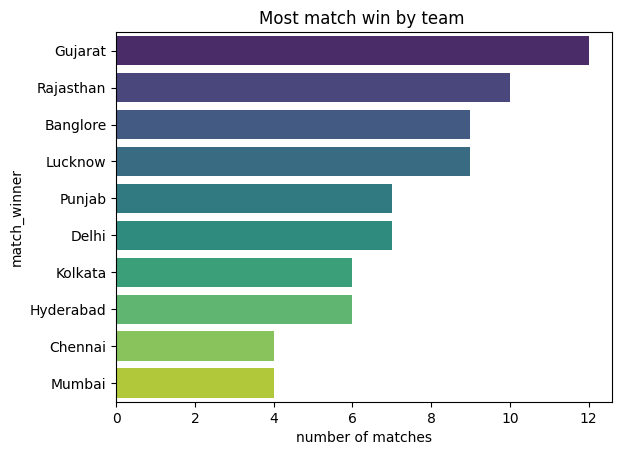

In [ ]:
match_wins=df['match_winner'].value_counts()
sns.barplot(x=match_wins.values,y=match_wins.index,palette="viridis")
plt.title("Most match win by team ")
plt.xlabel("number of matches")

2.Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends')

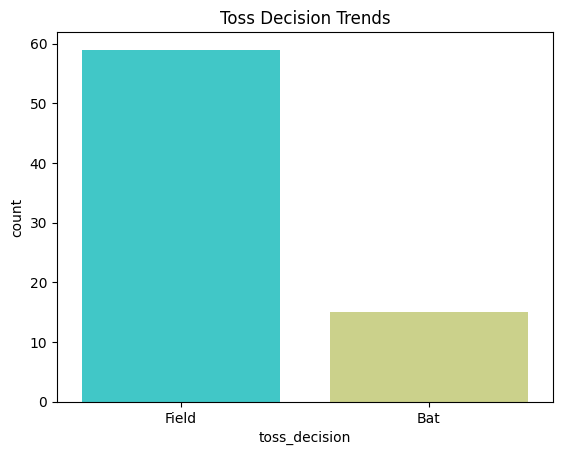

In [ ]:
sns.countplot(x=df['toss_decision'],palette='rainbow')
plt.title("Toss Decision Trends")


3.Winners vs Match Winners

In [ ]:
count=df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage=(count *100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

4.How to do teams win? (Runs vs Wickets)

Text(0.5, 1.0, 'Won by')

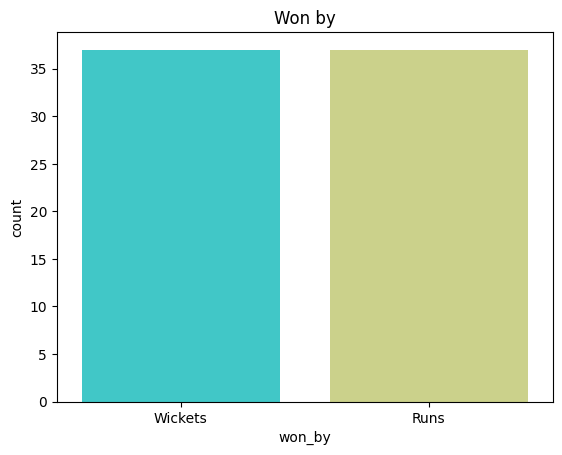

In [ ]:
sns.countplot(x=df['won_by'],palette='rainbow')
plt.title("Won by")


Key Players Information

1.Most Player of the Match Awards 

In [ ]:
count=df['player_of_the_match'].value_counts().head(10)
count

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Shubman Gill         2
Avesh Khan           2
Dinesh Karthik       2
Hardik Pandya        2
Rahul Tripathi       2
Name: count, dtype: int64

Text(0.0, 1.0, 'Top 10 players with Most man of the match')

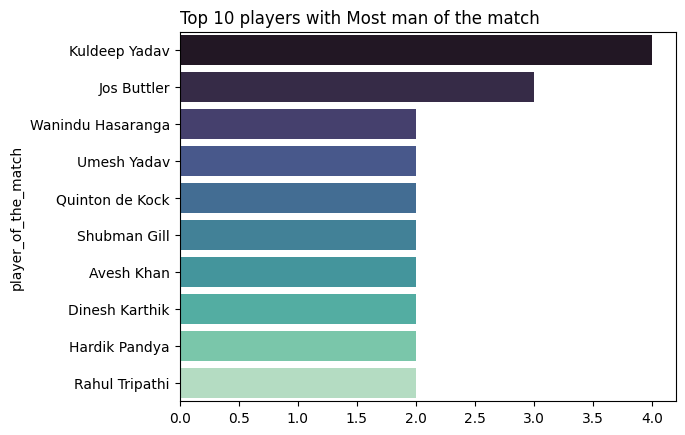

In [ ]:
sns.barplot(x=count.values,y=count.index,palette='mako')
plt.title("Top 10 players with Most man of the match",loc='left')


2 Top Scorer in league

In [ ]:

high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high



top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

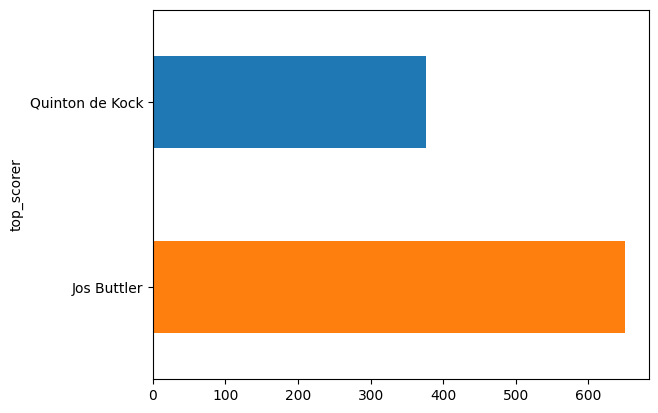

In [ ]:
high.plot(kind='barh',color=['tab:orange','tab:blue'])

10 Best Bowling Figures

In [ ]:
df['highest_wickets'] = df['best_bowling_figure'].apply(
    lambda x: int(x.split('--')[0]))
top_bowlers=df.groupby("best_bowling")["highest_wickets"].sum().sort_values(ascending=False).head(10)


Text(0.5, 0, 'wickets')

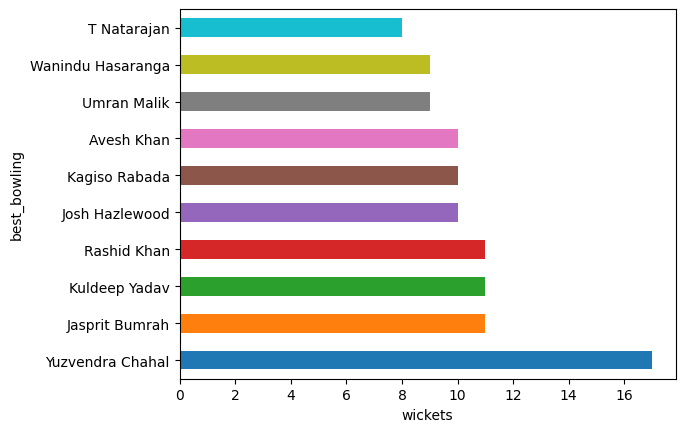

In [ ]:
top_bowlers.plot(kind='barh',color=plt.cm.tab10.colors)
plt.xlabel("wickets")

Venue Analysis

Most Matches by values

<Axes: ylabel='venue'>

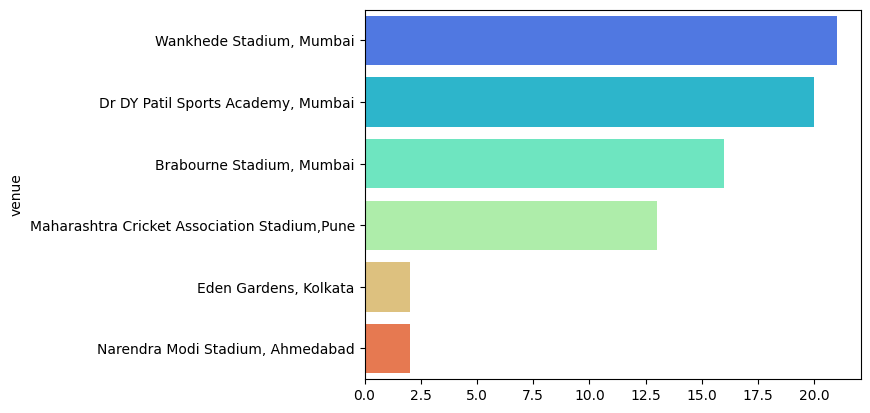

In [ ]:
venue_count=df['venue'].value_counts()
sns.barplot(y=venue_count.index,x=venue_count.values,palette='rainbow')

Custom Questions & Insights

Q1.Who won the highest margin by runs?

In [ ]:
df[df['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Q2.Which player has individual score?

In [ ]:
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Q3.Which bowler had the best bowling figures?

In [ ]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
